<a href="https://colab.research.google.com/github/SenTier1107/Appprogramming_2026/blob/main/Preprocessing_Skewed_Data_Transformation_diamonds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

원본 데이터 왜도: 1.6184


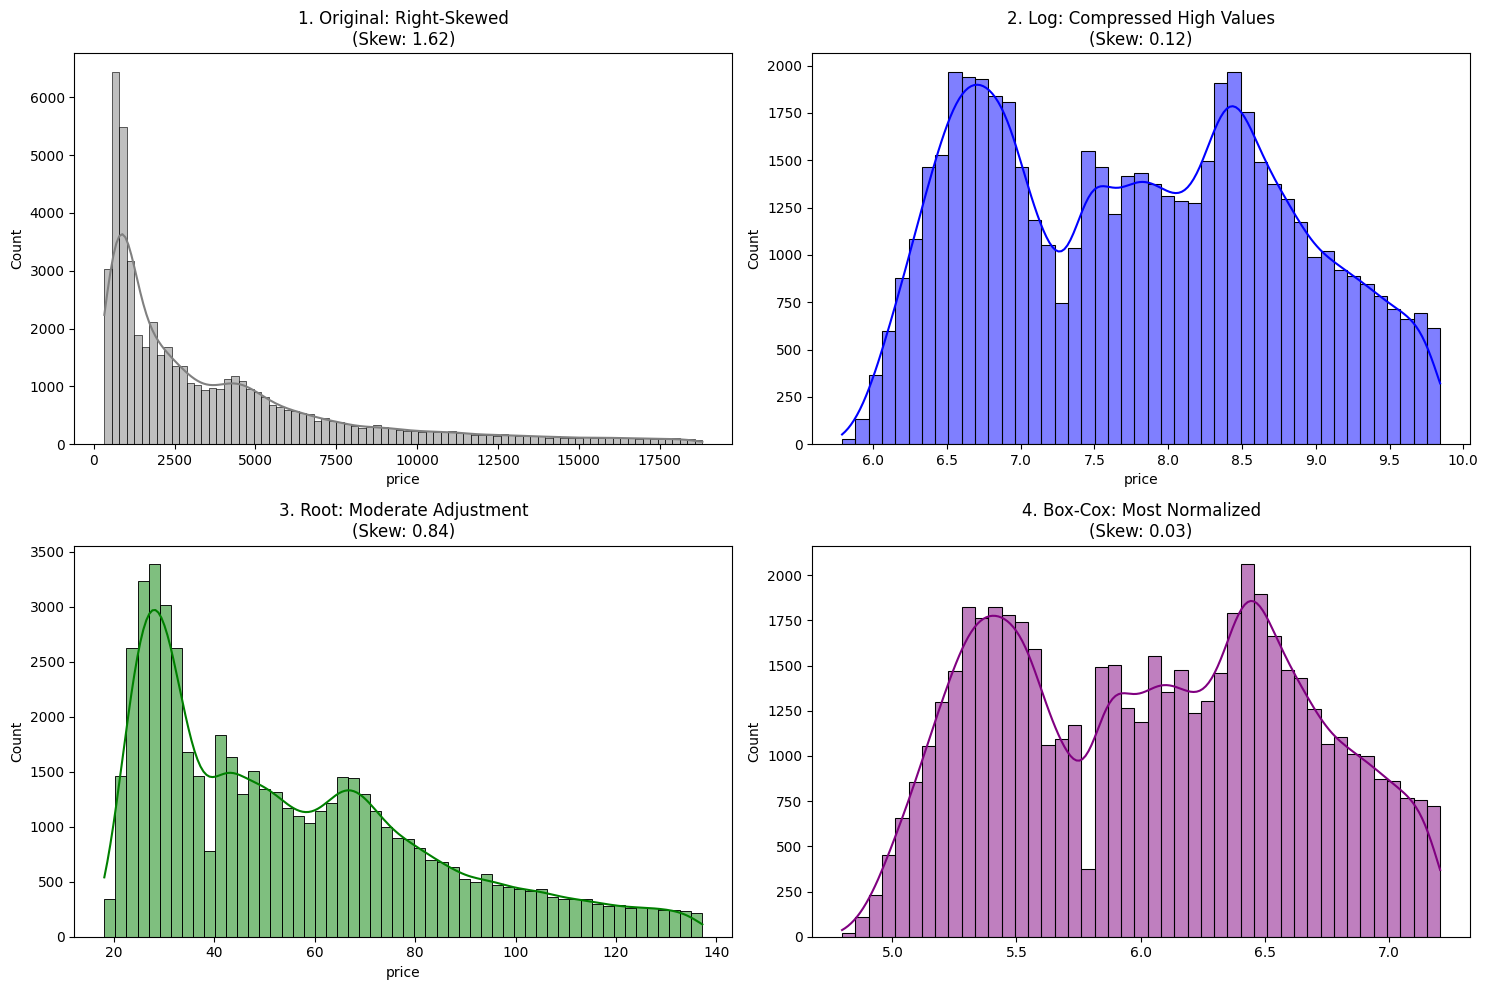

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. 데이터 로드: 다이아몬드 5만여 개의 가격, 크기 등의 정보가 담긴 데이터입니다.
diamonds = sns.load_dataset("diamonds")
price_data = diamonds['price']

# 2. 왜도(Skewness) 확인: 데이터가 한쪽으로 얼마나 치우쳤는지 수치로 봅니다.
# 0에 가까울수록 좌우 대칭인 종 모양(정규분포)입니다.
original_skew = price_data.skew()
print(f"원본 데이터 왜도: {original_skew:.4f}")

# 3. 데이터 변환 (Transformation):
# 목적: 가격처럼 '작은 값은 많고 큰 값은 적은' 불균형한 데이터를 골고루 퍼뜨립니다.

# (1) 로그 변환: 큰 값을 아주 작게 압축합니다. (가장 강력한 변환 방법)
log_transformed = np.log1p(price_data)

# (2) 루트 변환: 값에 루트를 씌워 큰 값의 크기를 줄입니다. (중간 강도)
root_transformed = np.sqrt(price_data)

# (3) 박스-콕스 변환: 통계적으로 '가장 정규분포에 가깝게' 만드는 최적의 수치를 자동으로 찾아 변환합니다.
boxcox_transformed, _ = stats.boxcox(price_data)

# 4. 시각화 (히스토그램): 변환 전후의 '분포 모양' 변화를 눈으로 확인합니다.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# [좌측 상단] 원본: 왼쪽으로 쏠려 있고 오른쪽 꼬리가 매우 깁니다.
sns.histplot(price_data, kde=True, ax=axes[0, 0], color='gray')
axes[0, 0].set_title(f'1. Original: Right-Skewed\n(Skew: {original_skew:.2f})')

# [우측 상단] 로그: 쏠림이 해결되어 종 모양에 가깝게 변했습니다.
sns.histplot(log_transformed, kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title(f'2. Log: Compressed High Values\n(Skew: {log_transformed.skew():.2f})')

# [좌측 하단] 루트: 원본보다는 낫지만 여전히 조금 왼쪽으로 쏠려 있습니다.
sns.histplot(root_transformed, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title(f'3. Root: Moderate Adjustment\n(Skew: {root_transformed.skew():.2f})')

# [우측 하단] 박스-콕스: 가장 예쁜 종 모양(정규분포)을 보여줍니다.
sns.histplot(boxcox_transformed, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title(f'4. Box-Cox: Most Normalized\n(Skew: {pd.Series(boxcox_transformed).skew():.2f})')

plt.tight_layout()
plt.show()

In [4]:
import seaborn as sns
sns.load_dataset("diamonds")

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
